<a href="https://colab.research.google.com/github/TcHaOcHeK/ML/blob/6/LR6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 4 - Многомерная регрессия
## Цель работы: ннаучиться решать задачу классификации методами решающих деревьев и ансамблей на их основе.

Датасет – wine.csv В мире представлено множество вин, включая десертные вина, игристые вина, газированные вина, столовые вина и марочные вина. Возникает вопрос, как узнать, какое вино хорошее, а какое нет. В наборе данных 6497 наблюдений и всего 12 при-знаков.

Набор данных включает следующие атрибуты:

* fixed acidity – уровень кислотности в вине
* volatile acidity – количество уксусной кислоты, присутствующей в вине
* citric acid – количество лимонной кислоты, присутствующей в вине
* residual sugar – количество сахара после ферментации
* chlorides – количество солей, присутствующих в вине
* free sulfur dioxide – количество SO2 в свободной форме
* total sulfur dioxide – количество свободных и связанных форм SO2
* density – плотность вина (масса/объем)
* pH – значение рН вина в диапазоне от 0 до 14
* sulphates – уровень содержания диоксида серы (SO2) в вине
* alcohol – количество алкоголя, присутствующего в вине
* quality – конечное качество упомянутого вина
* type – тип вина (красное, белое) – целевая переменная

## Импортируем библиотеки

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder


# Загрузка и первичный анализ данных

In [107]:
data = pd.read_csv("wine.csv")
data.head()
X = data.drop('type', axis = 1)
y = data['type']

In [108]:
print("Общая размерность данных:", X.shape)
print("Названия всех столбцов:", X.columns.tolist())
print("Уникальные значения в целевой переменной:", y.unique())
print("\nПервые 5 строк данных:")
print(X.head())

Общая размерность данных: (6497, 12)
Названия всех столбцов: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Уникальные значения в целевой переменной: ['red' 'white']

Первые 5 строк данных:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.

# Преобразуем категориальные данные в числовые

In [109]:
y = y.astype('category').cat.codes
y.head()

,0
0,0
1,0
2,0
3,0
4,0


# Разделение данных на обучающую и тестовую выборки

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

print(f"Размер обчающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обчающей выборки: (5197, 12)
Размер тестовой выборки: (1300, 12)


# Построение и оценка базового дерева решений

In [111]:
base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [112]:
# Делаем прогнозы
y_pred_base = base_dt.predict(X_test)

In [113]:
# Оцениваем точность
accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Точность базового дерева на тесте: {accuracy_base:.4f}")

Точность базового дерева на тесте: 0.9915


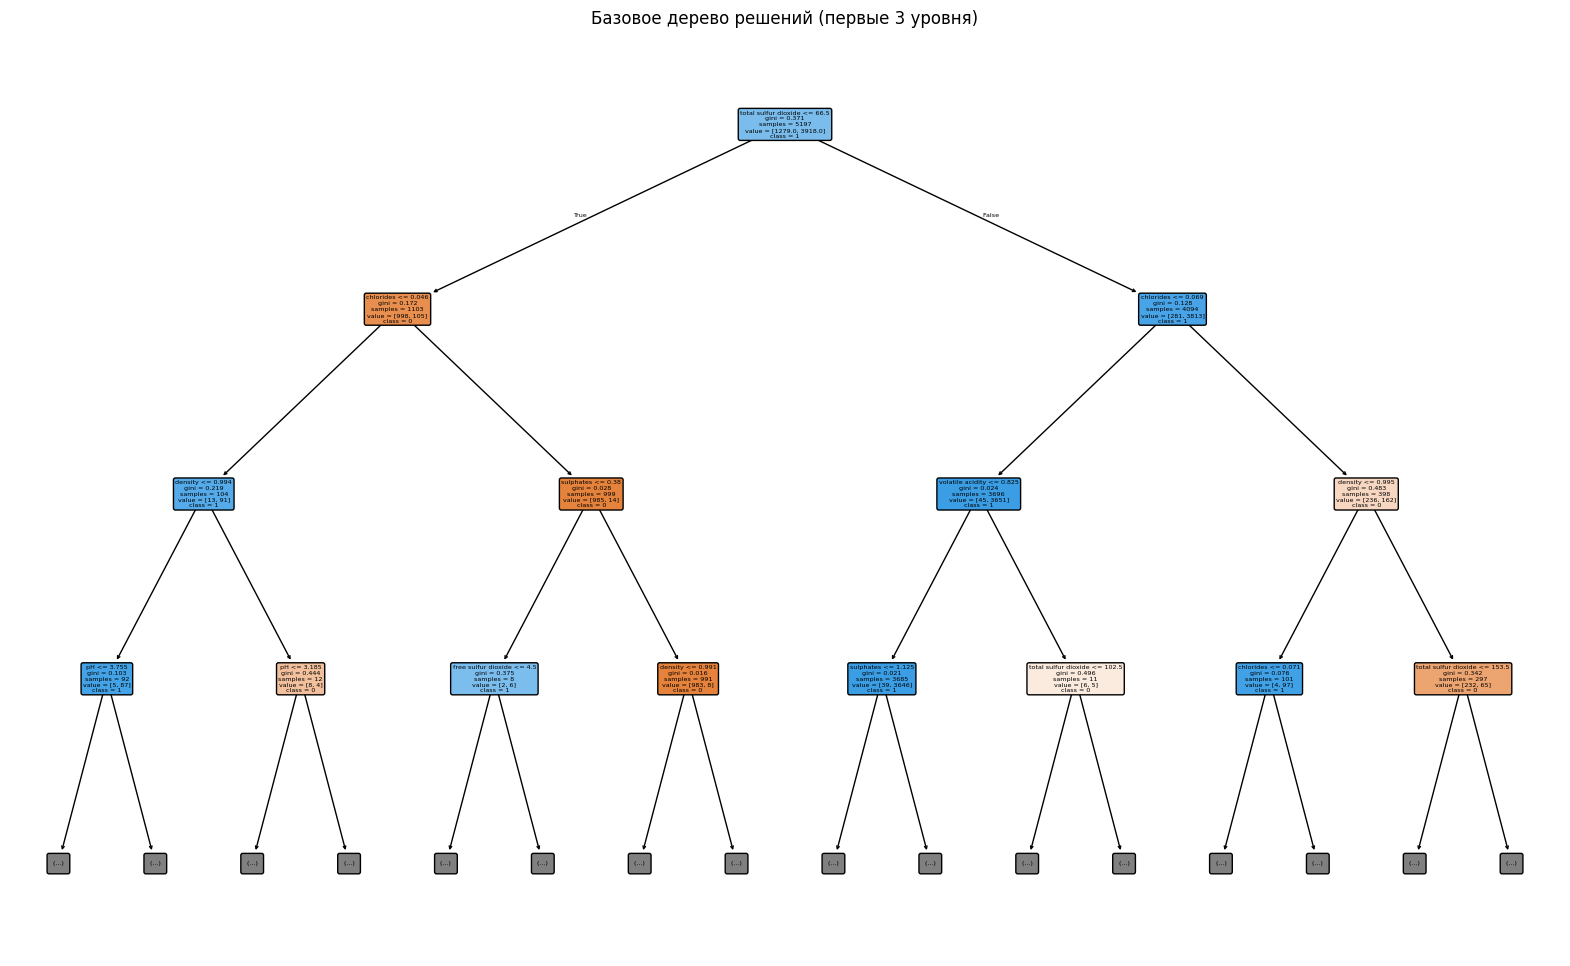

In [114]:
feature_names = X.columns.tolist()
class_names = sorted(y.astype(str).unique())

plt.figure(figsize=(20, 12))
plot_tree(base_dt, filled=True, feature_names=feature_names,class_names=class_names, rounded=True, max_depth=3)
plt.title("Базовое дерево решений (первые 3 уровня)")
plt.show()

# Борьба с переобучением: настройка гниперпарраметров

In [115]:
# Попробуем ограничить глубину дерева
tuned_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
tuned_dt.fit(X_train, y_train)

y_pred_tuned = tuned_dt.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Точность настроенного дерева (max_depth=3) на тесте: {accuracy_tuned:.4f}")

Точность настроенного дерева (max_depth=3) на тесте: 0.9708


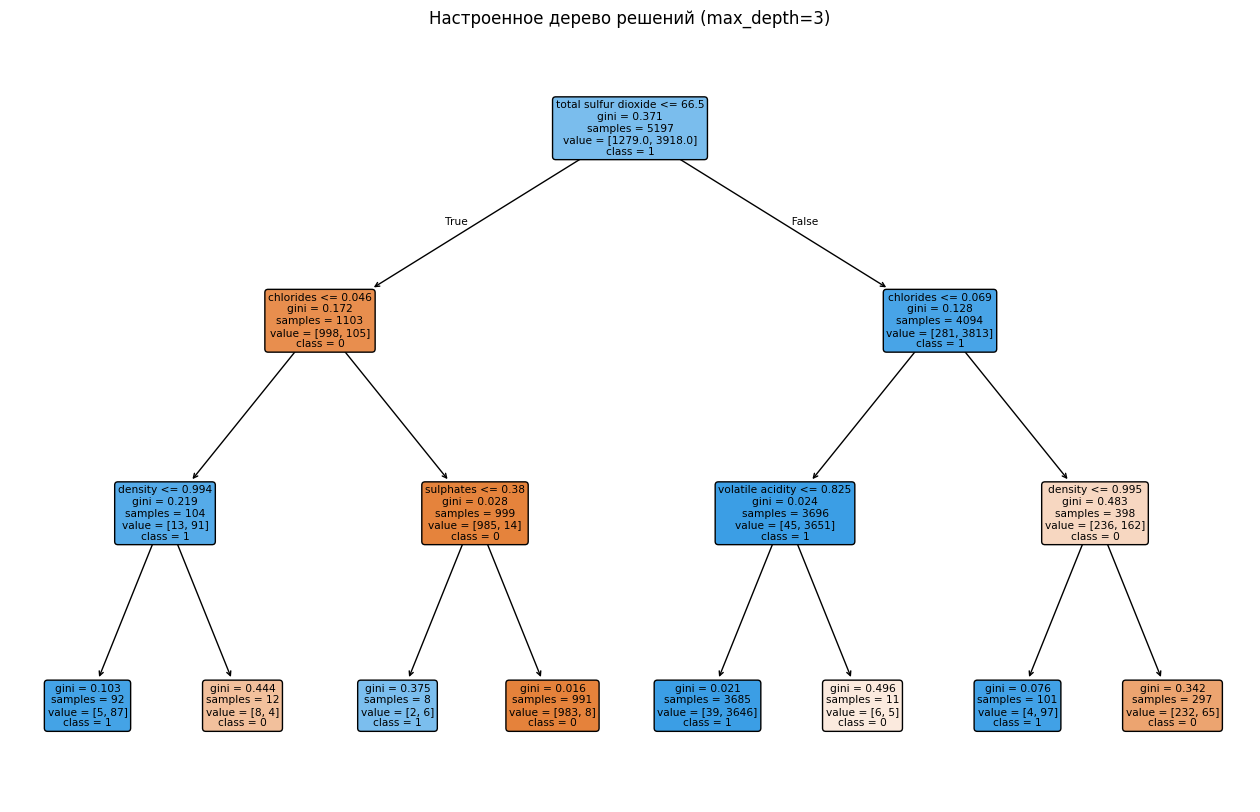

In [116]:
plt.figure(figsize=(16, 10))
plot_tree(tuned_dt, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
plt.title("Настроенное дерево решений (max_depth=3)")
plt.show()


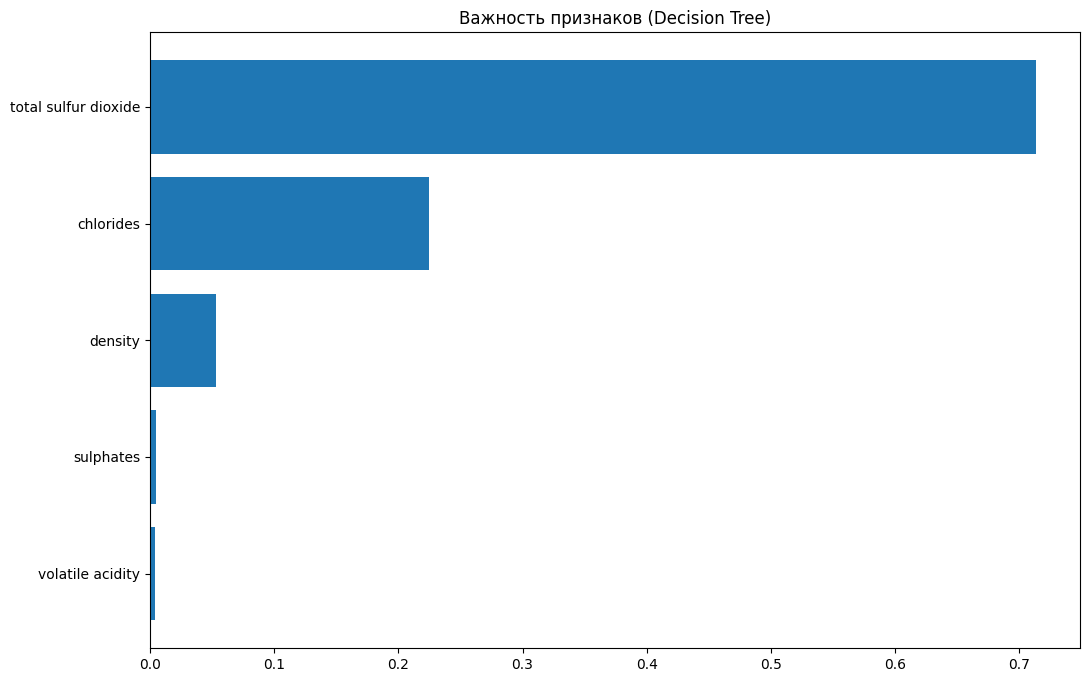

In [117]:
# Важность признаков
importances = tuned_dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Важность признаков (Decision Tree)")
plt.barh(range(5), importances[indices][:5]) # Топ-5 признака
plt.yticks(range(5), [X.columns[i] for i in indices[:5]])
plt.gca().invert_yaxis()
plt.show()

# Ансамбли: случайный лес (Бэггинг)

In [118]:
# Создаем и обучаем случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 деревьев
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [119]:
# Прогноз и оценка
y_pred = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Точность Случайного леса на тесте: {accuracy_rf:.4f}")

Точность Случайного леса на тесте: 0.9962


In [120]:
print('\n' + "="*50)
print("Отчет по классификации:")
print("="*50)
print(classification_report(y_test, y_pred, target_names = class_names))


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       320
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1300
   macro avg       0.99      1.00      0.99      1300
weighted avg       1.00      1.00      1.00      1300



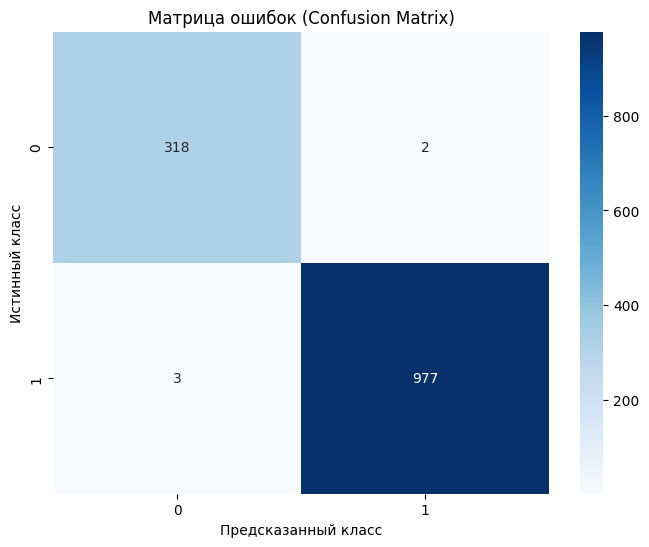

In [121]:
# Строим матрицу ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

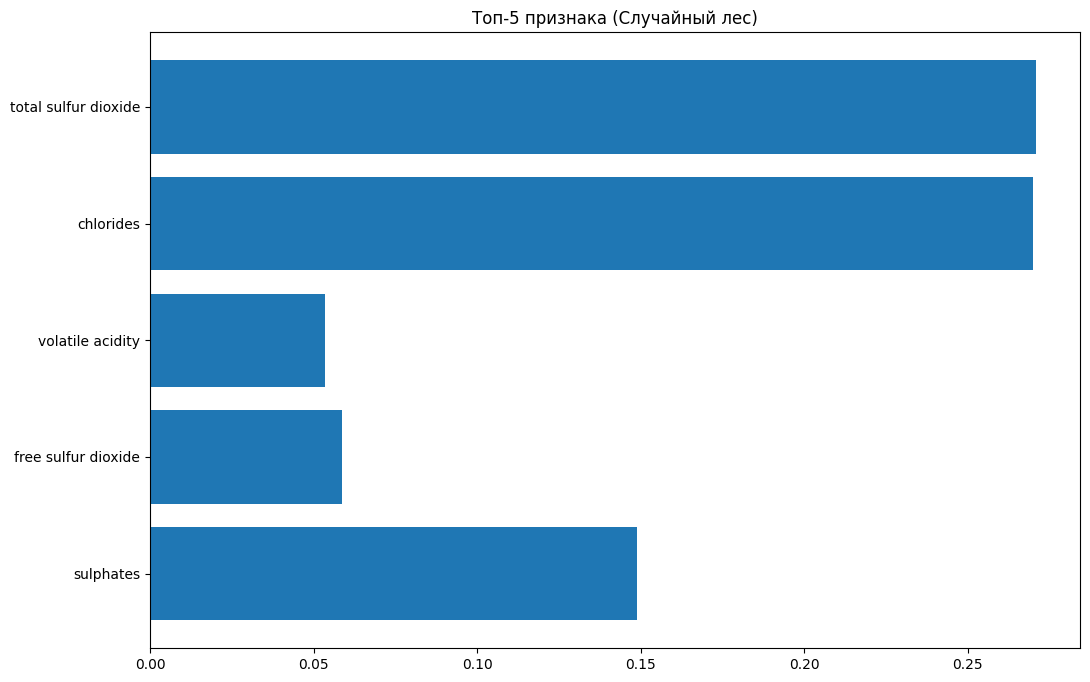

In [122]:
#выведем важные признаки случайного леса

rf_importances = rf.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Топ-5 признака (Случайный лес)")
plt.barh(range(5), rf_importances[indices][:5]) # Топ-5 признака
plt.yticks(range(5), [X.columns[i] for i in indices_rf[:5]])
plt.gca().invert_yaxis()
plt.show()

plt.show()

# Подбор гиперпараметров случайного дерева

In [123]:
from sklearn.model_selection import GridSearchCV
# Определяем сетку параметров для перебора
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [124]:
# Создаём модель для поиска
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [125]:
# Запускаем поиск
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [126]:
# Выводим лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность при кросс-валидации: {:.4f}".format(grid_search.best_score_))

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая точность при кросс-валидации: 0.9950


In [127]:
# Оцениваем лучшую модель на тестовых данных
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Точность улучшенной модели на тестовой выборке: {best_accuracy:.4f}")

Точность улучшенной модели на тестовой выборке: 0.9969


# Ансамбли: Градиентный бустинг

In [128]:
# Создаем и обучаем Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [129]:
# Прогноз и оценка
y_pred_gb = gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Точность Gradient Boosting на тесте: {accuracy_gb:.4f}")

Точность Gradient Boosting на тесте: 0.9954


# Сравнение всех моделей

In [130]:
# Создаем сводную таблицу результатов
models = {
    'Base Decision Tree': base_dt,
    'Tuned Decision Tree': tuned_dt,
    'Random Forest': best_rf_model,
    'Gradient Boosting': gb
}

results = {}
for name, model in models.items():
    # Считаем accuracy на тренировочном и тестовом наборах
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'Train Accuracy': train_acc, 'Test Accuracy': test_acc}

                     Train Accuracy  Test Accuracy
Base Decision Tree         1.000000       0.991538
Tuned Decision Tree        0.974601       0.970769
Random Forest              0.999230       0.996923
Gradient Boosting          0.998461       0.995385


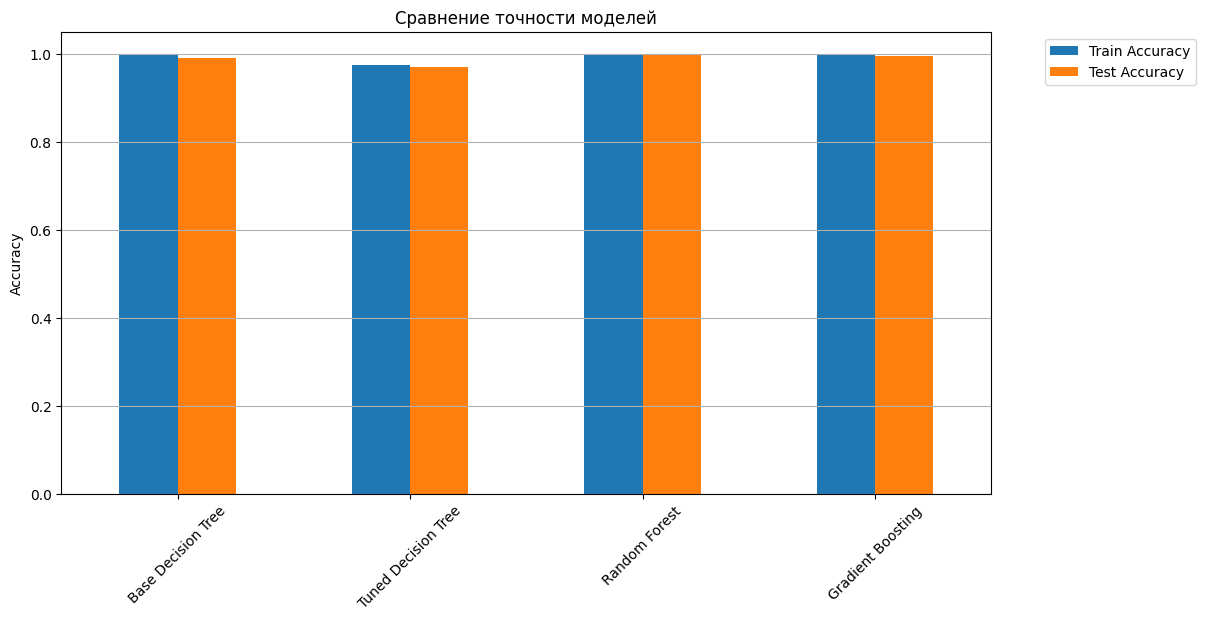

In [131]:
# Выводим результаты в виде DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Строим bar-plot для наглядности
results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(12, 6))
plt.title("Сравнение точности моделей")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.show()